In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import warnings

warnings.filterwarnings('ignore')

# ปรับ pandas display options
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)


# SECTION 1: LOAD DATA

In [2]:
# !unzip heart_disease_prediction.zip  # แตกไฟล์ถ้ายังไม่ได้แตก

train_df = pd.read_csv('train.csv')
print("=== Dataset Shape ===")
print(f"Rows: {train_df.shape[0]}, Columns: {train_df.shape[1]}")
print()
print("=== ตัวอย่างข้อมูล 5 แถวแรก ===")
print(train_df.head())

=== Dataset Shape ===
Rows: 223084, Columns: 20

=== ตัวอย่างข้อมูล 5 แถวแรก ===
             ID History of HeartDisease or Attack High Blood Pressure  \
0  train_000001                                No                 Yes   
1  train_000002                                No                  No   
2  train_000003                                No                 Yes   
3  train_000004                                No                 Yes   
4  train_000005                               NaN                 Yes   

  Told High Cholesterol Cholesterol Checked  Body Mass Index  \
0                   Yes                 Yes            40.68   
1                    No                  No            24.36   
2                   Yes                 Yes            27.33   
3                    No                 Yes            27.01   
4                   Yes                 Yes            34.56   

  Smoked 100+ Cigarettes Diagnosed Stroke Diagnosed Diabetes  \
0                    Yes       

# SECTION 2: DATA CLEANING

In [3]:
# --- 2.1 ตรวจสอบ Missing Values ---
print("\n=== Missing Values ก่อน Clean ===")
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])


=== Missing Values ก่อน Clean ===
                                   Missing Count  Missing %
History of HeartDisease or Attack           1694       0.76
Told High Cholesterol                      32186      14.43
Body Mass Index                            11782       5.28
Smoked 100+ Cigarettes                         1       0.00
Diagnosed Diabetes                             3       0.00
Doctor Visit Cost Barrier                      1       0.00
General Health                                 1       0.00
Difficulty Walking                             3       0.00


In [4]:
# --- 2.2 ตรวจสอบ Duplicated Rows ---
# [เพิ่มใหม่] โค้ดเดิมไม่มีขั้นตอนนี้
n_duplicates = train_df.duplicated().sum()
print(f"\n=== Duplicated Rows: {n_duplicates} ===")
if n_duplicates > 0:
    train_df = train_df.drop_duplicates()
    print(f"ลบ duplicates แล้ว เหลือ {len(train_df)} rows")


=== Duplicated Rows: 0 ===


In [5]:
# --- 2.3 ลบ Target ที่เป็น NaN ออก (ไม่สามารถ impute target ได้) ---
train_df = train_df.dropna(subset=['History of HeartDisease or Attack'])
print(f"\nหลังลบ Target NaN เหลือ {len(train_df)} rows")


หลังลบ Target NaN เหลือ 221390 rows


In [6]:
# --- 2.4 Impute Missing Values ---
# BMI: ใช้ Median เพราะ BMI มีการกระจายแบบ right-skewed (outlier สูง)
train_df['Body Mass Index'] = train_df['Body Mass Index'].fillna(train_df['Body Mass Index'].median())

In [7]:
# คอลัมน์ Binary/Categorical: ใช้ Mode (ค่าที่พบมากที่สุด)
cols_to_fix = [
    'Told High Cholesterol',
    'Diagnosed Diabetes',
    'Smoked 100+ Cigarettes',
    'Doctor Visit Cost Barrier',
    'General Health',
    'Difficulty Walking'
]
for col in cols_to_fix:
    train_df[col] = train_df[col].fillna(train_df[col].mode()[0])


In [ ]:
# ตรวจสอบอีกครั้งหลัง impute
print("\n=== Missing Values หลัง Clean ===")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])
print("ไม่มี Missing Values เหลืออยู่ ✓" if train_df.isnull().sum().sum() == 0 else "")


=== Missing Values หลัง Clean ===
Series([], dtype: int64)
ไม่มี Missing Values เหลืออยู่ ✓


# SECTION 3: OUTLIER DETECTION (IQR Method)

In [14]:
print("\n=== Outlier Detection: BMI (IQR Method) ===")
Q1 = train_df['Body Mass Index'].quantile(0.25)
Q3 = train_df['Body Mass Index'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

n_outliers = ((train_df['Body Mass Index'] < lower_bound) | (train_df['Body Mass Index'] > upper_bound)).sum()
print(f"IQR Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
print(f"Outliers ใน BMI: {n_outliers} rows ({n_outliers/len(train_df)*100:.2f}%)")
print(f"BMI Min (เดิม): {train_df['Body Mass Index'].min():.2f}, Max (เดิม): {train_df['Body Mass Index'].max():.2f}")



=== Outlier Detection: BMI (IQR Method) ===
IQR Range: [13.96, 40.88]
Outliers ใน BMI: 0 rows (0.00%)
BMI Min (เดิม): 13.96, Max (เดิม): 40.88


In [15]:
# Cap ค่า BMI แทนการลบ เพราะ BMI สูงหรือต่ำมากอาจเกิดขึ้นจริงในทางการแพทย์
# แต่ค่าสุดโต่งอาจ bias model ได้
train_df['Body Mass Index'] = train_df['Body Mass Index'].clip(lower=lower_bound, upper=upper_bound)
print(f"BMI หลัง Cap: Min={train_df['Body Mass Index'].min():.2f}, Max={train_df['Body Mass Index'].max():.2f}")


BMI หลัง Cap: Min=13.96, Max=40.88


Text(0.5, 0, 'BMI')

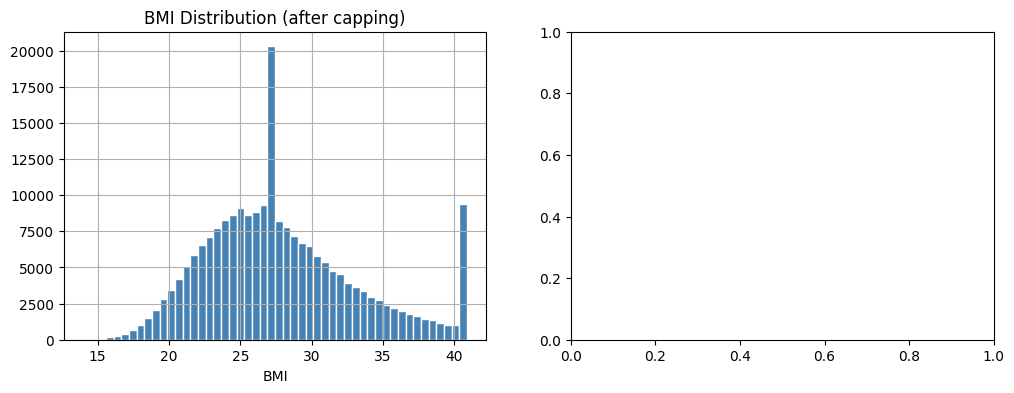

In [16]:
# Plot distribution ของ BMI หลัง cap
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['Body Mass Index'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('BMI Distribution (after capping)')
axes[0].set_xlabel('BMI')


In [19]:
# ตรวจสอบ outlier
Q1_age = train_df['Age'].quantile(0.25)
Q3_age = train_df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
n_outliers_age = ((train_df['Age'] < Q1_age - 1.5*IQR_age) | (train_df['Age'] > Q3_age + 1.5*IQR_age)).sum()
sns.histplot(train_df['Age'], bins=50, ax=axes[1], color='coral')
axes[1].set_title(f'Age Distribution (outliers: {n_outliers_age})')
axes[1].set_xlabel('Age')
plt.tight_layout()
plt.savefig('outlier_distributions.png', dpi=100, bbox_inches='tight')
plt.show()
print("บันทึก outlier_distributions.png แล้ว")


<Figure size 640x480 with 0 Axes>

บันทึก outlier_distributions.png แล้ว


# SECTION 4: ENCODING (แปลง Categorical → Numeric)

In [20]:
# --- 4.1 Binary columns: Yes → 1, No → 0 ---
binary_cols = [
    'History of HeartDisease or Attack',
    'High Blood Pressure', 'Told High Cholesterol', 'Cholesterol Checked',
    'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes',
    'Leisure Physical Activity', 'Heavy Alcohol Consumption',
    'Health Care Coverage', 'Doctor Visit Cost Barrier',
    'Difficulty Walking', 'Vegetable or Fruit Intake (1+ per Day)'
]
for col in binary_cols:
    train_df[col] = train_df[col].map({'Yes': 1, 'No': 0})


In [21]:
# --- 4.2 Ordinal encoding: General Health (มี order ชัดเจน) ---
health_map = {'Very Poor': 1, 'Poor': 2, 'Fair': 3, 'Good': 4, 'Excellent': 5}
train_df['General Health'] = train_df['General Health'].map(health_map)


In [22]:
# --- 4.3 Sex ---
train_df['Sex'] = train_df['Sex'].map({'Male': 1, 'Female': 0})


In [23]:
# --- 4.4 Education Level: One-Hot Encoding ---
train_df = pd.get_dummies(train_df, columns=['Education Level'], drop_first=True)


In [24]:
# --- 4.5 Income Level: Ordinal (มี order ชัดเจนตามรายได้) ---
income_map = {
    'Less than $10,000': 1,
    '($10,000 to less than $15,000': 2,   # หมายเหตุ: ข้อมูลเดิมมี '(' นำหน้า
    '$15,000 to less than $20,000': 3,
    '$20,000 to less than $25,000': 4,
    '$25,000 to less than $35,000': 5,
    '$35,000 to less than $50,000': 6,
    '$50,000 to less than $75,000': 7,
    '$75,000 or more': 8
}
train_df['Income Level'] = train_df['Income Level'].map(income_map)

print("\n=== ข้อมูลหลัง Encoding ===")
print(train_df.dtypes)


=== ข้อมูลหลัง Encoding ===
ID                                                   object
History of HeartDisease or Attack                     int64
High Blood Pressure                                   int64
Told High Cholesterol                                 int64
Cholesterol Checked                                   int64
Body Mass Index                                     float64
Smoked 100+ Cigarettes                                int64
Diagnosed Stroke                                      int64
Diagnosed Diabetes                                    int64
Leisure Physical Activity                             int64
Heavy Alcohol Consumption                             int64
Health Care Coverage                                  int64
Doctor Visit Cost Barrier                             int64
General Health                                        int64
Difficulty Walking                                    int64
Sex                                                   int64
Income Leve

# SECTION 5: FEATURE ANALYSIS & SELECTION


In [25]:
# --- 5.1 Correlation กับ Target ---
features_to_check = [
    'History of HeartDisease or Attack',  # Target
    'High Blood Pressure',
    'Told High Cholesterol',
    'Body Mass Index',
    'Smoked 100+ Cigarettes',
    'Diagnosed Stroke',
    'Diagnosed Diabetes',
    'General Health',
    'Age',
    'Income Level',
    # [เพิ่มใหม่] features อื่นที่ควรพิจารณา
    'Difficulty Walking',
    'Heavy Alcohol Consumption',
    'Leisure Physical Activity',
    'Sex',
]

selected_corr = train_df[features_to_check].corr()
heart_corr = selected_corr[['History of HeartDisease or Attack']].sort_values(
    by='History of HeartDisease or Attack', ascending=False
)
print("\n=== Correlation กับ Target (เรียงจากมากไปน้อย) ===")
print(heart_corr)


=== Correlation กับ Target (เรียงจากมากไปน้อย) ===
                                   History of HeartDisease or Attack
History of HeartDisease or Attack                           1.000000
Age                                                         0.231322
High Blood Pressure                                         0.218911
Difficulty Walking                                          0.214661
Diagnosed Stroke                                            0.208151
Told High Cholesterol                                       0.196574
Diagnosed Diabetes                                          0.175597
Smoked 100+ Cigarettes                                      0.110857
Sex                                                         0.076425
Body Mass Index                                             0.065399
Heavy Alcohol Consumption                                  -0.028308
Leisure Physical Activity                                  -0.077110
Income Level                                       

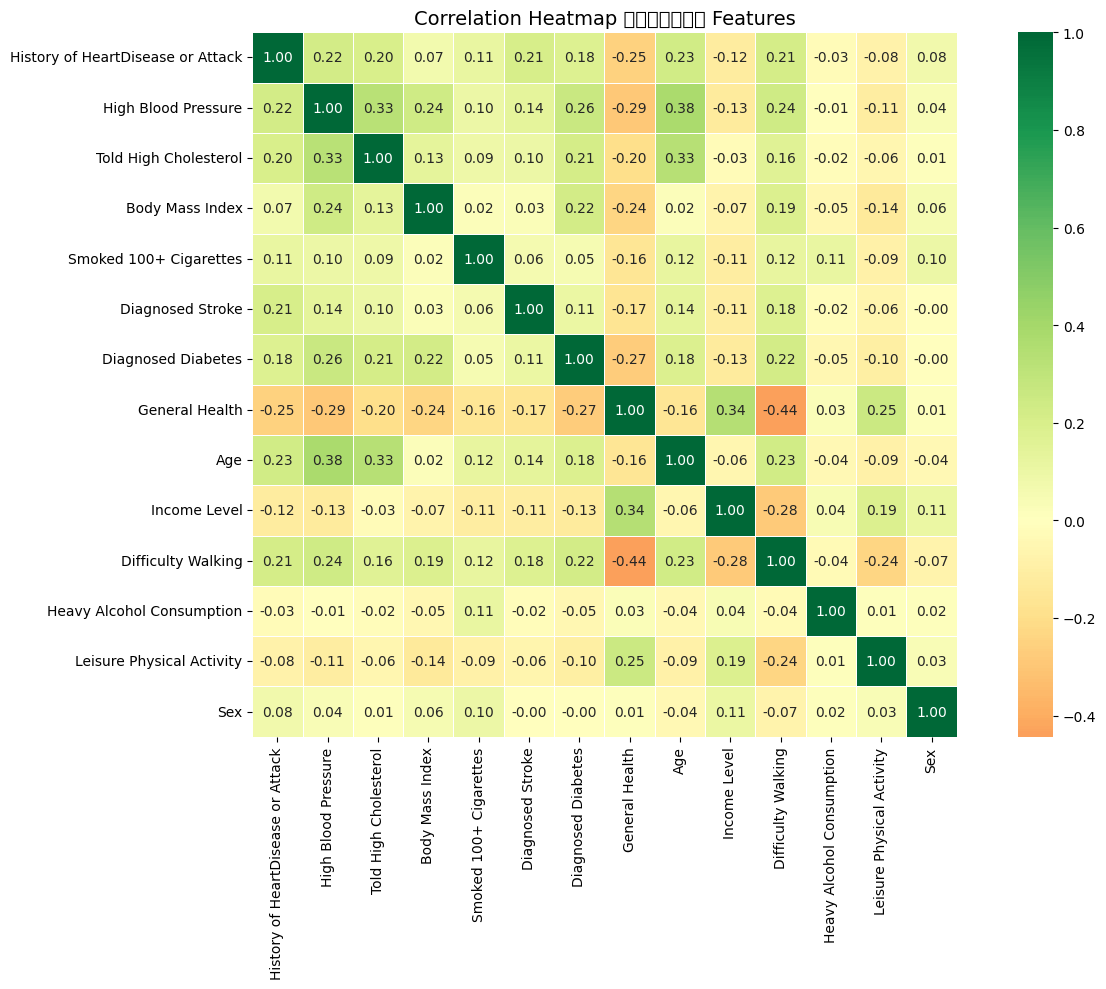

บันทึก correlation_heatmap.png แล้ว


In [26]:
# --- 5.2 Plot Correlation Heatmap ---
# [เพิ่มใหม่] Heatmap เพื่อดู multicollinearity ระหว่าง features
plt.figure(figsize=(14, 10))
sns.heatmap(
    selected_corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    linewidths=0.5, square=True
)
plt.title('Correlation Heatmap ระหว่าง Features', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print("บันทึก correlation_heatmap.png แล้ว")

In [27]:
# --- 5.3 Target Distribution ---
# [เพิ่มใหม่] ตรวจสอบ class imbalance
target_counts = train_df['History of HeartDisease or Attack'].value_counts()
print(f"\n=== Target Distribution ===")
print(target_counts)
print(f"Class Ratio (0:1) = {target_counts[0]/target_counts[1]:.1f}:1")
print("⚠️ ข้อมูลไม่สมดุล (Imbalanced) → ใช้ class_weight='balanced' ใน Model")



=== Target Distribution ===
History of HeartDisease or Attack
0    203322
1     18068
Name: count, dtype: int64
Class Ratio (0:1) = 11.3:1
⚠️ ข้อมูลไม่สมดุล (Imbalanced) → ใช้ class_weight='balanced' ใน Model


# SECTION 6: FEATURE SELECTION & TRAIN/TEST SPLIT

In [28]:
# เลือก features ที่มี correlation สูงกับ target (|corr| > 0.05)
# และ features ที่มีความหมายทางการแพทย์
selected_features = [
    'High Blood Pressure',
    'Told High Cholesterol',
    'Body Mass Index',
    'Smoked 100+ Cigarettes',
    'Diagnosed Stroke',
    'Diagnosed Diabetes',
    'General Health',
    'Age',
    'Income Level',
    'Difficulty Walking',        # [เพิ่มใหม่] corr สูง ควรใส่
    'Heavy Alcohol Consumption', # [เพิ่มใหม่]
    'Leisure Physical Activity', # [เพิ่มใหม่]
    'Sex',                       # [เพิ่มใหม่]
]

In [29]:
X = train_df[selected_features]
y = train_df['History of HeartDisease or Attack']

In [30]:
print(f"\n=== Features ที่ใช้ Train: {len(selected_features)} features ===")
print(selected_features)


=== Features ที่ใช้ Train: 13 features ===
['High Blood Pressure', 'Told High Cholesterol', 'Body Mass Index', 'Smoked 100+ Cigarettes', 'Diagnosed Stroke', 'Diagnosed Diabetes', 'General Health', 'Age', 'Income Level', 'Difficulty Walking', 'Heavy Alcohol Consumption', 'Leisure Physical Activity', 'Sex']


In [31]:
from sklearn.model_selection import train_test_split

# Stratify=y เพื่อให้สัดส่วน class ใน train/test เท่ากัน
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")



Train size: 177112 | Test size: 44278


# SECTION 7: FEATURE SCALING


In [32]:
from sklearn.preprocessing import StandardScaler

# Scale เฉพาะ continuous features (BMI, Age)
# [ปรับปรุง] โค้ดเดิม scale ทุก feature รวมถึง binary ซึ่งไม่จำเป็น
# แต่ยังคง scale ทั้งหมดเพื่อ compatibility กับ Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SECTION 8: MODEL TRAINING & COMPARISON


In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

In [34]:
# --- Model 1: Logistic Regression (โค้ดเดิม) ---
print("\n=== Model 1: Logistic Regression ===")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")



=== Model 1: Logistic Regression ===
              precision    recall  f1-score   support

           0       0.98      0.76      0.86     40664
           1       0.23      0.79      0.35      3614

    accuracy                           0.76     44278
   macro avg       0.60      0.78      0.60     44278
weighted avg       0.92      0.76      0.81     44278

ROC-AUC: 0.8566


In [35]:
# --- Model 2: Random Forest ---
# [เพิ่มใหม่] เพิ่ม model ที่เหมาะกับ imbalanced data
print("\n=== Model 2: Random Forest ===")
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)  # RF ไม่จำเป็นต้อง scale

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred_rf))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}")



=== Model 2: Random Forest ===
              precision    recall  f1-score   support

           0       0.93      0.98      0.95     40664
           1       0.41      0.13      0.20      3614

    accuracy                           0.91     44278
   macro avg       0.67      0.56      0.58     44278
weighted avg       0.89      0.91      0.89     44278

ROC-AUC: 0.8148


# SECTION 9: MODEL EVALUATION & VISUALIZATION


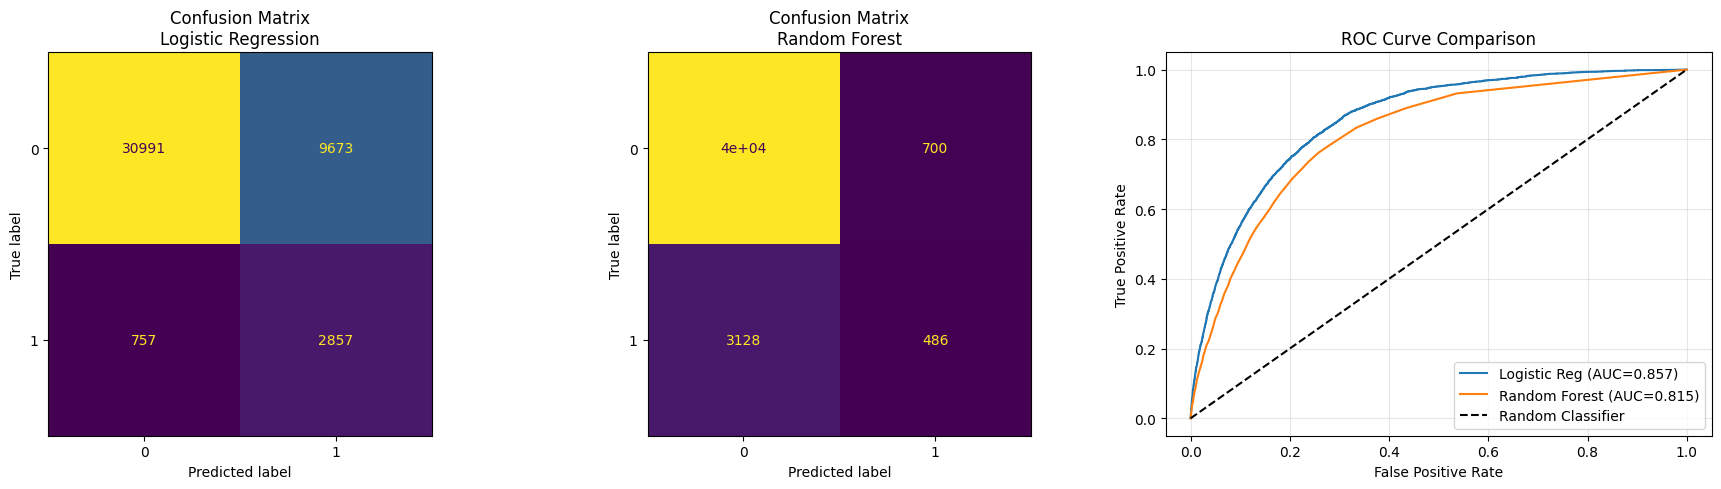


บันทึก model_evaluation.png แล้ว


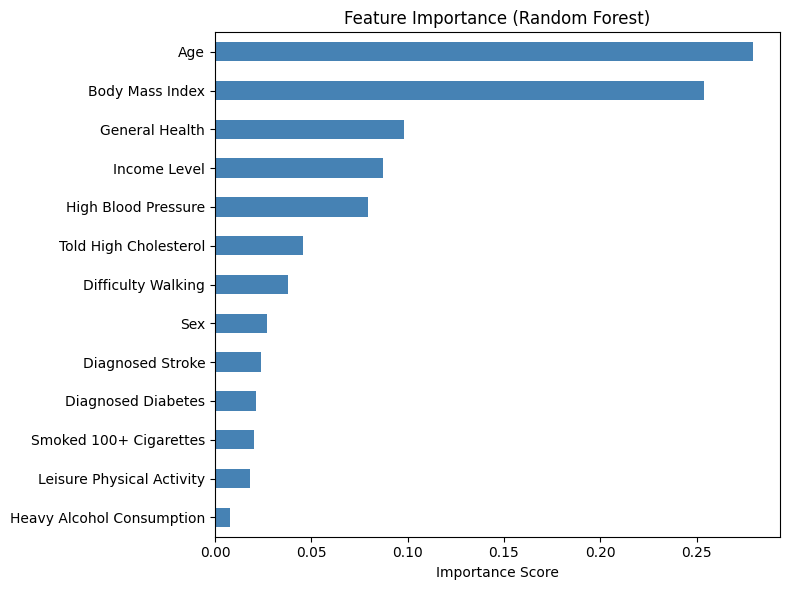

บันทึก feature_importance.png แล้ว

=== สรุปผลการเปรียบเทียบ Model ===
              Model  ROC-AUC
Logistic Regression   0.8566
      Random Forest   0.8148


In [43]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- 9.1 Confusion Matrix: Logistic Regression ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix\nLogistic Regression')

# --- 9.2 Confusion Matrix: Random Forest ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix\nRandom Forest')

# --- 9.3 ROC Curve เปรียบเทียบ ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nบันทึก model_evaluation.png แล้ว")

# --- 9.4 Feature Importance (Random Forest) ---
# [เพิ่มใหม่] ดูว่า feature ไหนสำคัญที่สุด
feat_importance = pd.Series(rf_model.feature_importances_, index=selected_features)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("บันทึก feature_importance.png แล้ว")

# --- 9.5 สรุปเปรียบเทียบ Model ---
print("\n=== สรุปผลการเปรียบเทียบ Model ===")
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4)
    ]
})
print(summary.to_string(index=False))

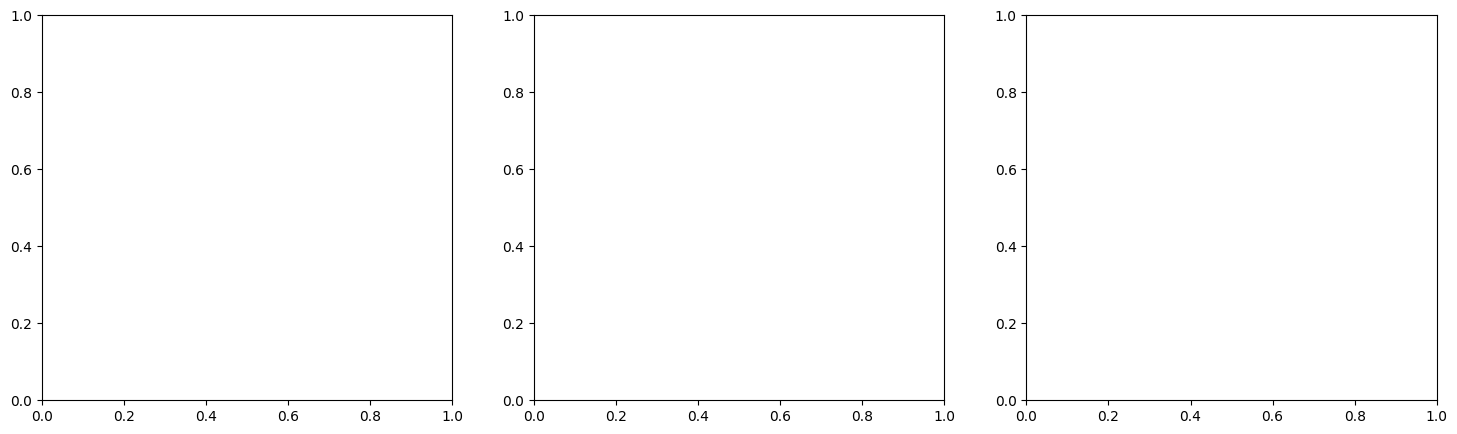

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

In [37]:
# --- 9.1 Confusion Matrix: Logistic Regression ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix\nLogistic Regression')


Text(0.5, 1.0, 'Confusion Matrix\nLogistic Regression')

In [38]:
# --- 9.2 Confusion Matrix: Random Forest ---
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf, ax=axes[1], colorbar=False)
axes[1].set_title('Confusion Matrix\nRandom Forest')

Text(0.5, 1.0, 'Confusion Matrix\nRandom Forest')

In [39]:
# --- 9.3 ROC Curve เปรียบเทียบ ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

axes[2].plot(fpr_lr, tpr_lr, label=f'Logistic Reg (AUC={roc_auc_score(y_test, y_prob_lr):.3f})')
axes[2].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.3f})')
axes[2].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].set_title('ROC Curve Comparison')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=100, bbox_inches='tight')
plt.show()
print("\nบันทึก model_evaluation.png แล้ว")

<Figure size 640x480 with 0 Axes>


บันทึก model_evaluation.png แล้ว


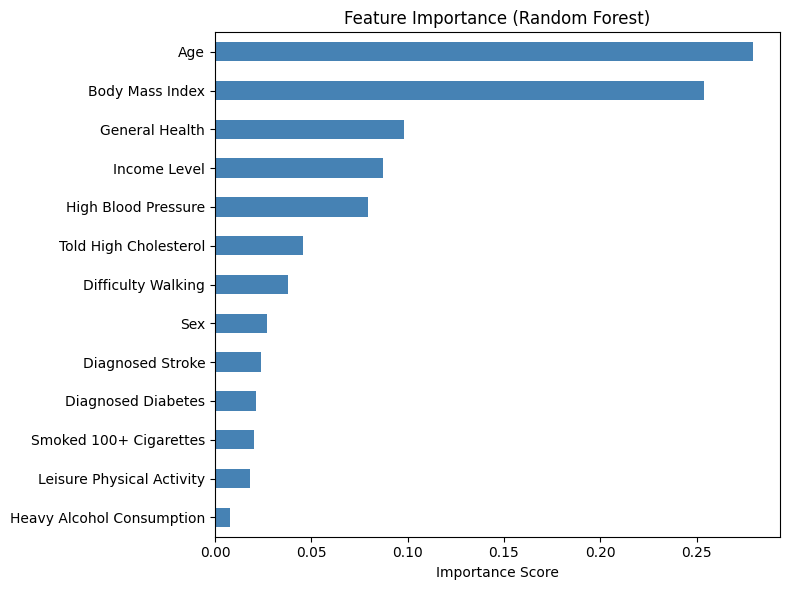

บันทึก feature_importance.png แล้ว


In [40]:
# --- 9.4 Feature Importance (Random Forest) ---
# [เพิ่มใหม่] ดูว่า feature ไหนสำคัญที่สุด
feat_importance = pd.Series(rf_model.feature_importances_, index=selected_features)
feat_importance = feat_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
feat_importance.plot(kind='barh', color='steelblue')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print("บันทึก feature_importance.png แล้ว")


In [41]:
# --- 9.5 สรุปเปรียบเทียบ Model ---
print("\n=== สรุปผลการเปรียบเทียบ Model ===")
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC-AUC': [
        round(roc_auc_score(y_test, y_prob_lr), 4),
        round(roc_auc_score(y_test, y_prob_rf), 4)
    ]
})
print(summary.to_string(index=False))



=== สรุปผลการเปรียบเทียบ Model ===
              Model  ROC-AUC
Logistic Regression   0.8566
      Random Forest   0.8148


# SECTION 10: SAVE BEST MODEL

In [42]:
# เลือก model ที่ดีกว่าตาม ROC-AUC
best_model_name = 'Random Forest' if roc_auc_score(y_test, y_prob_rf) > roc_auc_score(y_test, y_prob_lr) else 'Logistic Regression'
best_model = rf_model if best_model_name == 'Random Forest' else lr_model
print(f"\n=== Best Model: {best_model_name} ===")

joblib.dump(lr_model, 'logistic_heart_model.pkl')
joblib.dump(rf_model, 'rf_heart_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("บันทึก models และ scaler เรียบร้อยแล้ว!")


=== Best Model: Logistic Regression ===
บันทึก models และ scaler เรียบร้อยแล้ว!


# SECTION 11: PREDICTION ON TEST DATA

In [44]:
# Mapping Dictionaries (รวมไว้ในที่เดียว แทนที่จะกระจายหลาย cell)
clean_map = {'Yes': 1, 'No': 0, 'yes': 1, 'no': 0, 'Male': 1, 'Female': 0}

def preprocess_test(test_df, scaler, selected_features, health_map, income_map):
    """
    ฟังก์ชัน preprocess ข้อมูล test ให้เหมือนกับตอน train
    แยกออกมาเป็นฟังก์ชันเพื่อให้โค้ดเป็นระเบียบและ reusable
    """
    # แปลง Yes/No → 0/1
    test_df = test_df.replace(clean_map)

    # Ordinal encoding
    test_df['General Health'] = test_df['General Health'].map(health_map)
    test_df['Income Level'] = test_df['Income Level'].map(income_map)

    # One-Hot Encoding (Education)
    test_df = pd.get_dummies(test_df, columns=['Education Level'], drop_first=True)

    # เลือก features และ scale
    X_test_final = test_df[selected_features]
    X_test_scaled = scaler.transform(X_test_final)

    return X_test_final, X_test_scaled

In [45]:
# โหลดและ preprocess ข้อมูล test
test_df = pd.read_csv('test.csv')
X_test_final, X_test_final_scaled = preprocess_test(
    test_df, scaler, selected_features, health_map, income_map
)

In [46]:
# โหลด model และทำนาย
loaded_model = joblib.load('logistic_heart_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

predictions = loaded_model.predict(X_test_final_scaled)
probabilities = loaded_model.predict_proba(X_test_final_scaled)[:, 1]


In [47]:
# สร้าง submission file
answer = pd.DataFrame()
answer['ID'] = test_df['ID']
answer['History of HeartDisease or Attack'] = pd.Series(predictions).map({1: 'Yes', 0: 'No'})
# [เพิ่มใหม่] บันทึก probability ด้วยเพื่อ reference
# answer['Risk_Probability'] = probabilities.round(4)

answer.to_csv('submission_results.csv', index=False)
print("\n=== ทำนายผลเสร็จสิ้น! ===")
print(f"บันทึก submission_results.csv แล้ว ({len(answer)} rows)")
print(answer.head(10))


=== ทำนายผลเสร็จสิ้น! ===
บันทึก submission_results.csv แล้ว (74361 rows)
            ID History of HeartDisease or Attack
0  test_000001                                No
1  test_000002                                No
2  test_000003                               Yes
3  test_000004                                No
4  test_000005                                No
5  test_000006                               Yes
6  test_000007                               Yes
7  test_000008                               Yes
8  test_000009                               Yes
9  test_000010                                No
